<a href="https://colab.research.google.com/github/sanganalasya-hash/Data-Science/blob/main/Copy_of_Unit8Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Your file on your github needs to be a a .ipynb file with the first four letters of one first name, the first four letters of one last name, and U6proj.

Ex1.

A student named Avy Aguacate Avocado Palta will submit a file named "Avy_AvocU8proj.ipynb", since she normally just goes by Avy, and, when pressed, reports Avocado as her last name. The " _ " after "Avy" serves as the fourth "letter" in her first name.

Ex2.

Army Armadillo will submit a file named "ArmyArmaU8proj.ipynb"

# Unit 8 Project: Writing a BARTical

**Task**:

Two parts:

1. Propose a data set that's compatible with a pymc_bart model. I must approve your submission before you move on to part 2.

2. Create, analyze, and present BART model, using pymc_bart within the colab environment, on a data set of your choice, with the following conditions:
  - your final model must have more than 2 predictors. The intercept term doesn't count as a predictor here (even though technically it is)
  - You must argue why your variable selection is justified. You may use either a theoretical or numerical argument. Additionally, you must comment on any potential interactions between your predictor variables.



Guidlines:

- Your data or your model type must be different from any project you've previously done.

- You are allowed to copy and paste any code from the notes, including my answer key (AK), without any reference or citations. Same goes for the course textbook, BAP3.

- This is an individual project. It is fine if you model the same process as a peer, but your raw data **must** be substantially different. "Substantially different" means that I, your instructor, arbitrarily think your data sets are different enough.

- Do not look at other student's code/jupyter notebooks. Copying, or copying and pasting, other students code will result in a failing grade. Also, I will tell all the other teachers I know that you cheated.

- If you want to know what another student did, ask them--any verbal communication about a project is allowed and encouraged. If you want to see a graphic they made, ask them to sketch a picture of it for you by hand.

- Any handwritten communication is also allowed and encouraged, so long as all parties are in the same physical location together. Example: you may sketch out a piece of code while verbally explaining to someone what you did. Do NOT: hand write the code for your entire project, take a picture, and send it to everyone in the course.

- If you use someone's code from outside this course (like from the internet, an AI, or your parent), you must ask me if it is ok, and you must cite them in your work. I don't care all they did was to click your space bar one more time: you tell me, and you cite their contribution. You don't need to tell me about or cite verbal or handwritten communication though.

- You may use a more complicated model--like something from further along in the course--IF I give you permission.

- If you are unsure whether or not something is ok or allowed: ASK BEFORE YOU DO IT.

Faliure to adhere to these guidlines will result in a failing grade.

Tips:

- Try to pick something that you care about, have knowledge of, experience with, or that you find interesting/cool.

- Gather data *before* picking a model or likelihood.

-  Use your best idea now; maybe you can look at the context you used in the previous project, and gather different data from it.

- Choose a data set with lots of columns, and lots of potential interactions between variables. It'll be more fun, and will make model/variable selection more relevant.

- Comment heavily, and explain your steps and thought process with text blocks. This is not only requried, it'll also help you understand what you're doing and what you want to do.

- Its ok to pick a data set for which you don't qute understand the context--so long as you think the context is cool.


In [ ]:
!pip install pymc-bart
import pymc_bart as pmb

In [2]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import graphviz as gv

In [3]:
#drop the incomplete rows from the data
url="https://raw.githubusercontent.com/sanganalasya-hash/Data-Science/refs/heads/main/housing.csv"
house = pd.read_csv(url).dropna()

# Context
I looked at the california housing data set which evaluated how different variables effect each other. I chose this because I wanted a diverse dataset to practice using BART

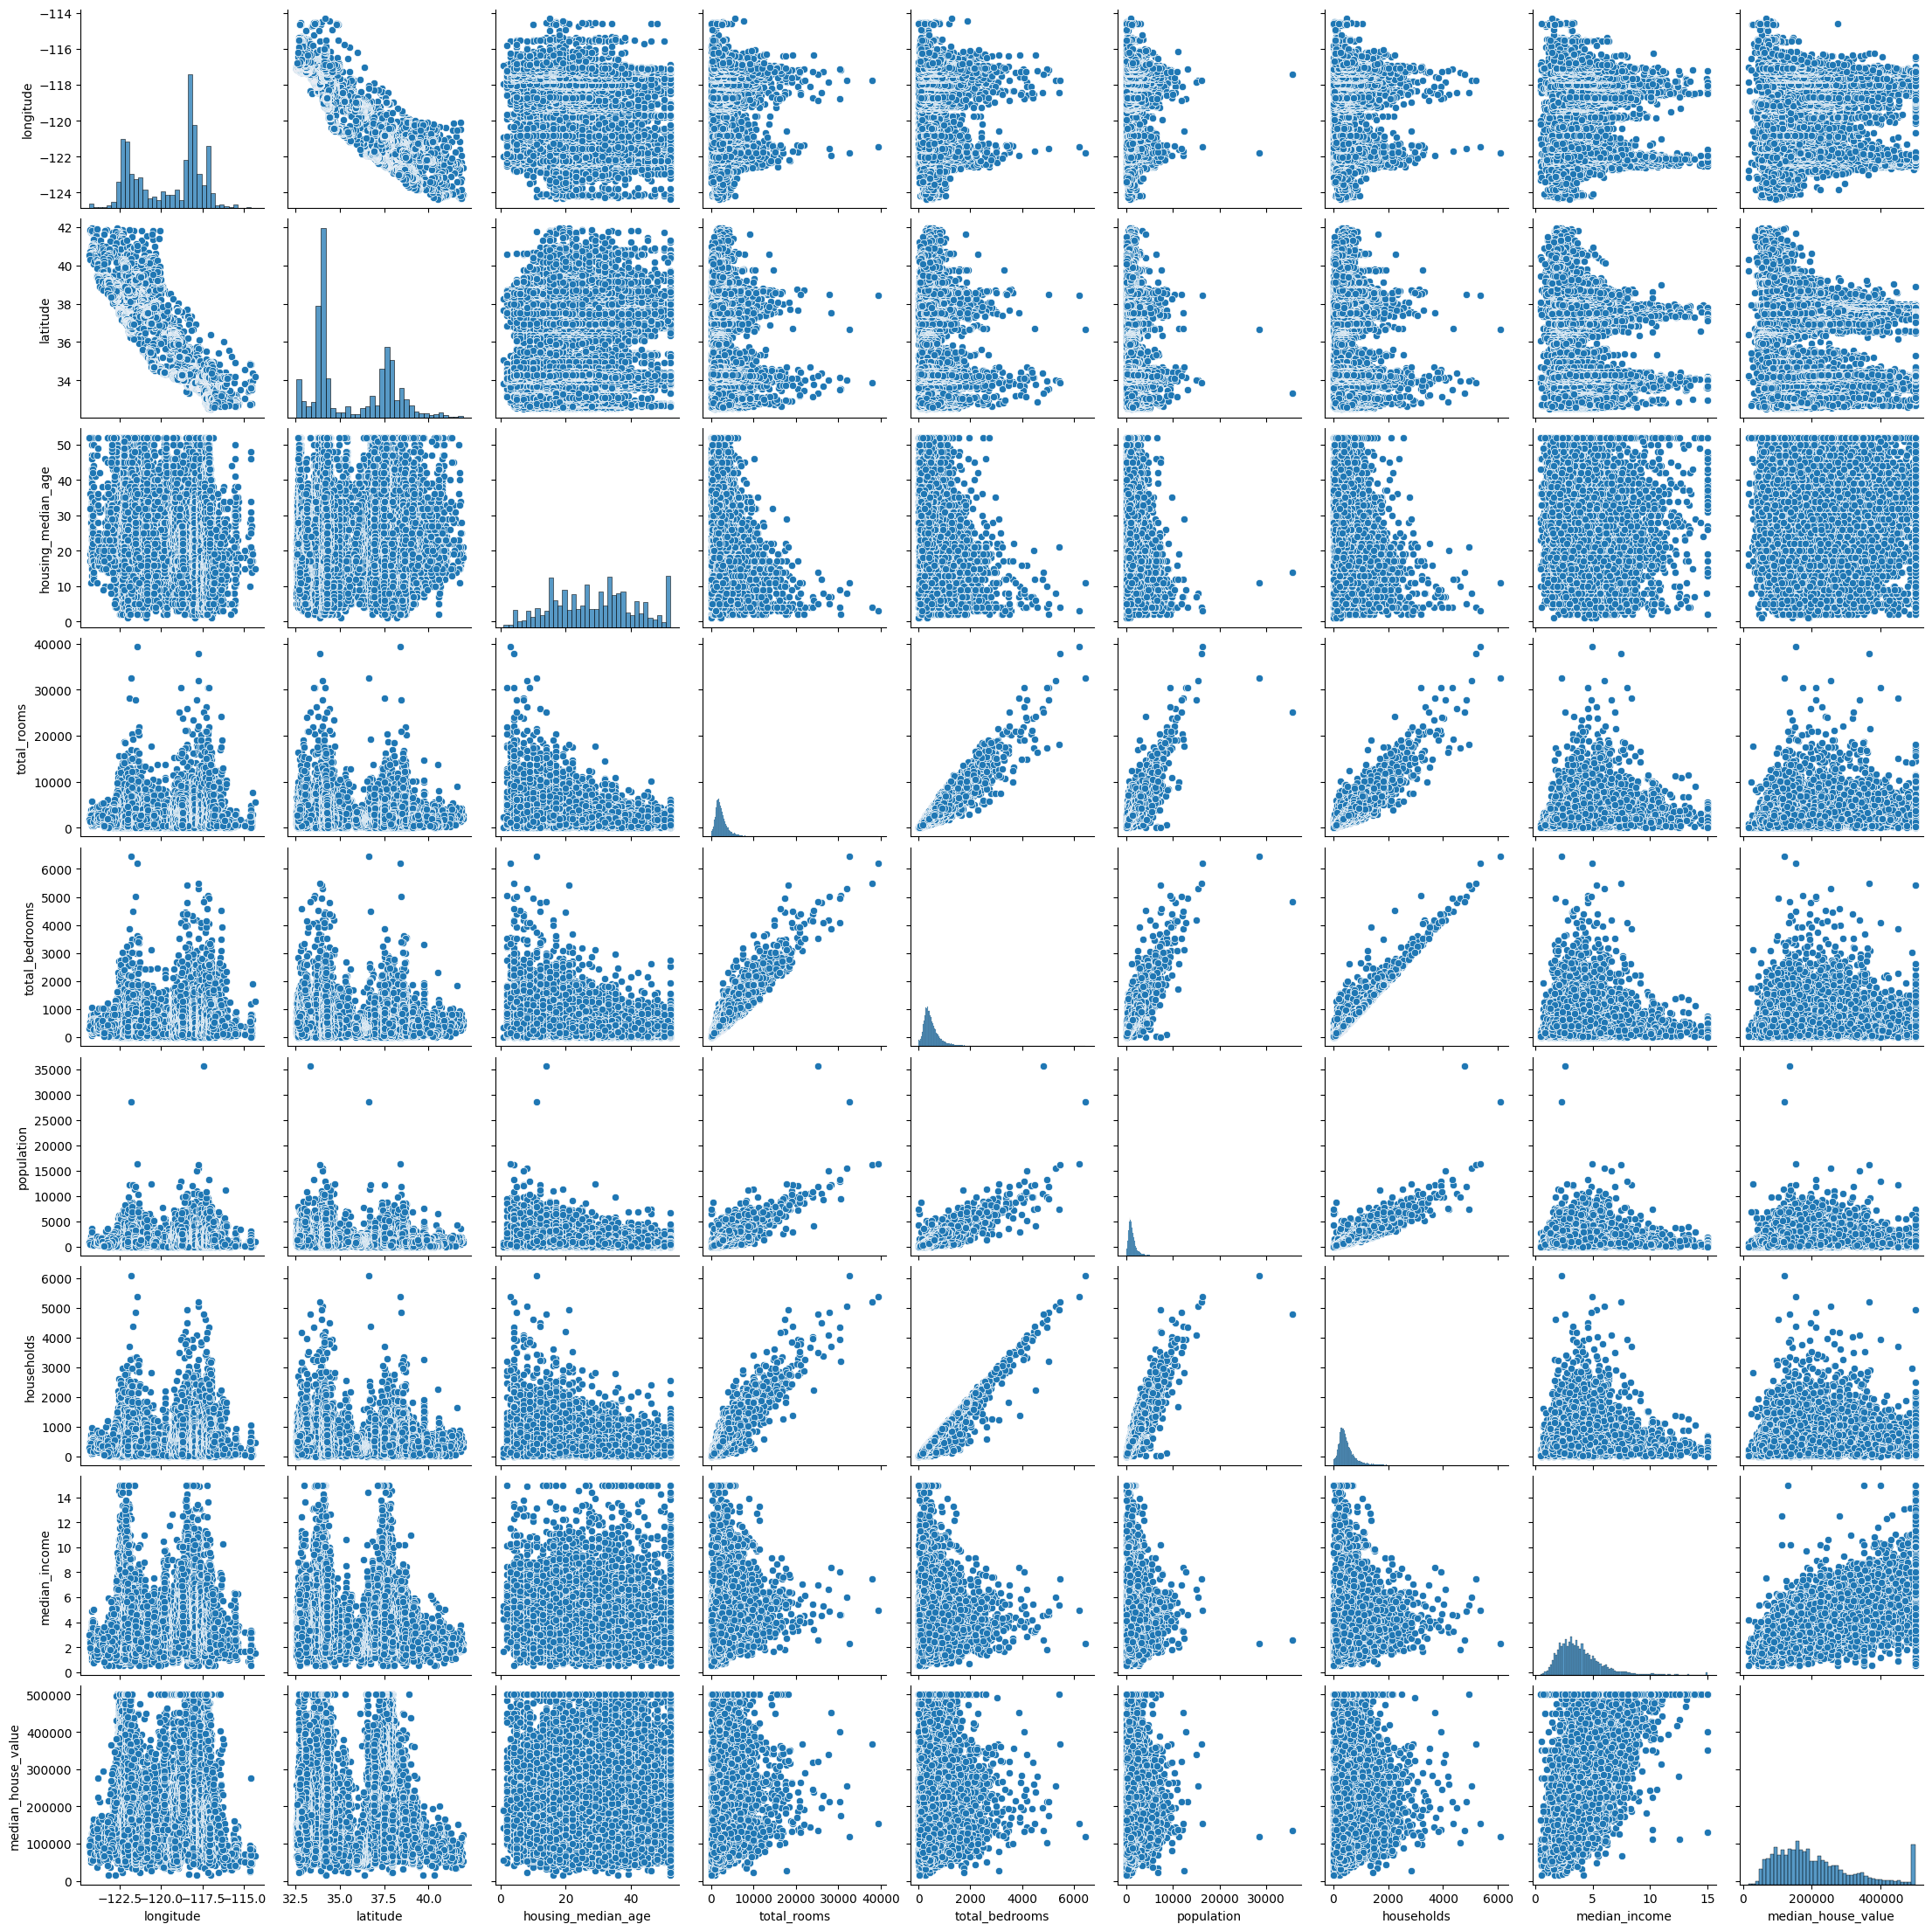

In [ ]:
sns.pairplot(house)

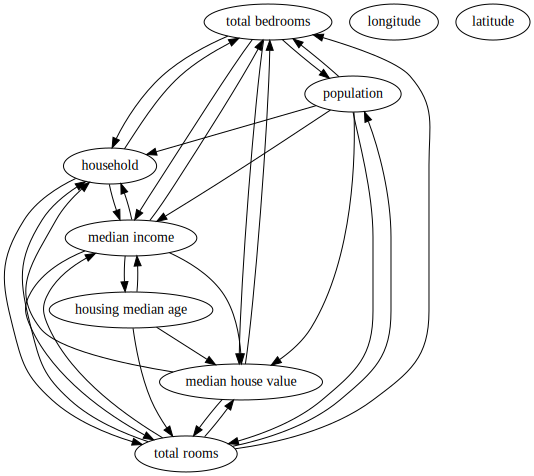

In [ ]:
octodag = gv.Digraph(name="OctoDAG")

octodag.node('T','total bedrooms')
octodag.node('L','longitude')
octodag.node('A','latitude')
octodag.node('M','housing median age')
octodag.node('R','total rooms')
octodag.node('P','population')
octodag.node('I','median income')
octodag.node('V','median house value')
octodag.node('H','household')

octodag.edges(['IV', 'PV', 'RV', 'MV', 'TV', 'IH', 'VH', 'PH', 'RH', 'TH', 'PI', 'RI', 'MI', 'TI', 'RP', 'TP', 'HI', 'PR', 'VR', 'MR', 'HR', 'IR', 'IM', 'RT', 'PT', 'HT', 'VT', 'IT'])

octodag

# Causual Diagram
After dissecting all the relationships betwween the varaibles i decided to predict households, or how many families are living in one house

In [4]:
features = ["total_bedrooms", "population", "median_income", "total_rooms", "median_house_value"]
X = house[features].to_numpy()
Y = house["households"].to_numpy()

In [ ]:
with pm.Model() as model_counties:
    s = pm.HalfNormal('s',20) #sigma = 20 is a blind guess
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50) #log around Y
    μ = pm.Deterministic("μ",pm.math.exp(μ_)) #exp it all once BART is done
    y = pm.Gamma("y", mu=μ, sigma=s,  observed=Y) #likelihood
    idata_counties = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_counties,model_counties, extend_inferencedata=True)

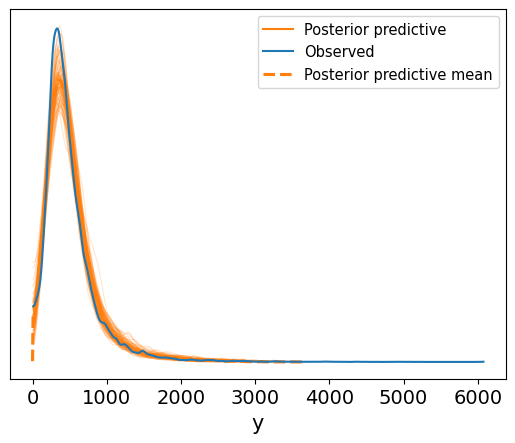

In [9]:
ax = az.plot_ppc(idata_counties, num_pp_samples=100, colors=["C1", "C0", "C1"])


# PPC Check
the model does a good job at predicting the observed data. This shows that the gamma likelihood was probably a good one for the data and there was likely some skew

In [10]:

posterior_mean = idata_counties.posterior["μ"]

μ_hdi = az.hdi(ary=idata_counties, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_counties, group="posterior_predictive", var_names=["y"]
).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


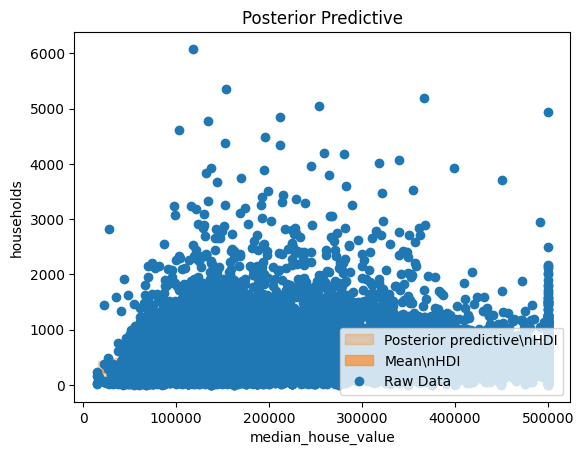

In [42]:
idx = np.argsort(X[:, 4]) #grab 'median_house_value' for sorting
fig, ax = plt.subplots()

az.plot_hdi(
    x=X[:, 4],
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior predictive\nHDI"},
)

az.plot_hdi(
    x=X[:, 4],
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean\nHDI"},
)
ax.plot(X[:, 4][idx], Y[idx], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="median_house_value",
    ylabel="households"
);

# Single Variable PPC
My posterior predictive is at the bottom and can't really be seen. This suggests households probably isn't strongly explained by median household value.

array([<Axes: xlabel='X_0'>, <Axes: xlabel='X_1'>, <Axes: xlabel='X_2'>,
       <Axes: xlabel='X_3'>, <Axes: xlabel='X_4'>], dtype=object)

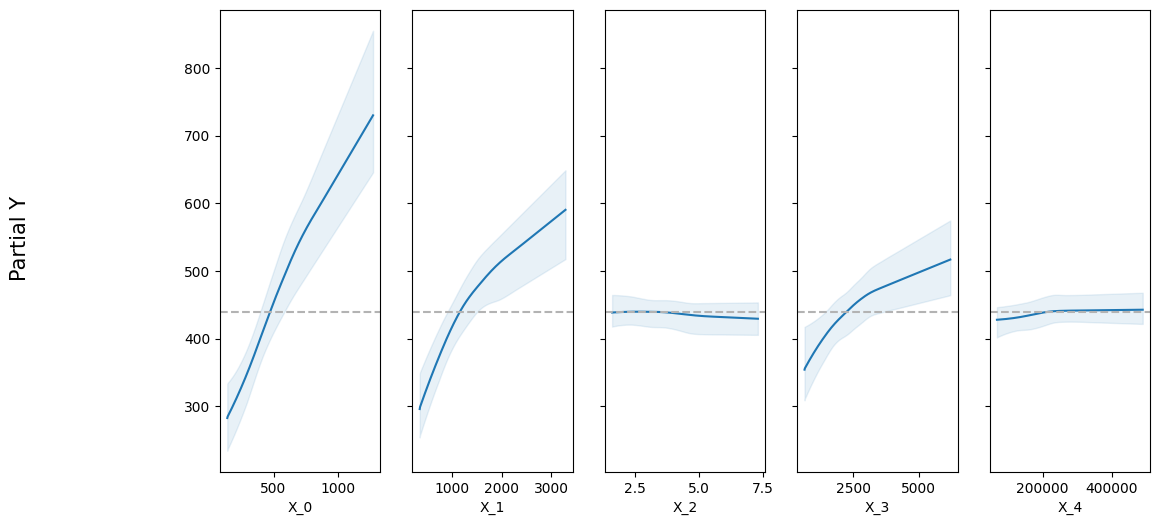

In [15]:
pmb.plot_pdp(μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

# PDPs

Bedrooms is a strong predicter and has a strong postitive relationship. Total rooms has a similar relationship but bedrooms especially is clearly a good predictor. Median income and house valye are both almost flat and are probably not adding a lot to the model. Population is a moderate predictor --- there's some relationship

array([<Axes: xlabel='X_0'>, <Axes: xlabel='X_1'>, <Axes: xlabel='X_2'>,
       <Axes: xlabel='X_3'>, <Axes: xlabel='X_4'>], dtype=object)

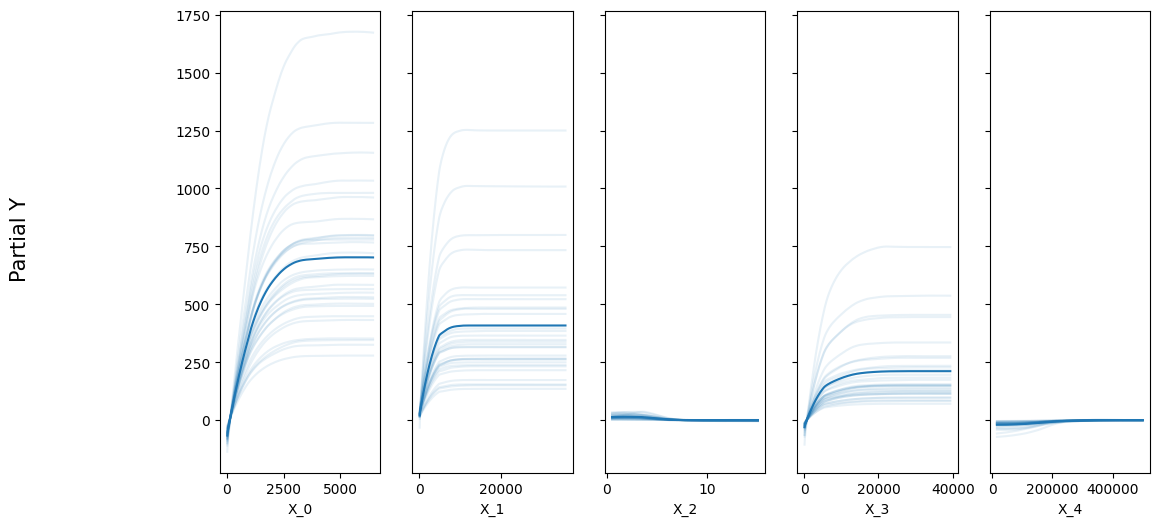

In [16]:
pmb.plot_ice( μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

# Ice
There is some lines crossing between total bedrooms and rooms suggesting some interactions. This makes sense --- total bedrooms would also affect the total number of rooms in the house.

In [17]:
vi_counties = pmb.compute_variable_importance(idata_counties, μ_, X)

<Axes: ylabel='R²'>

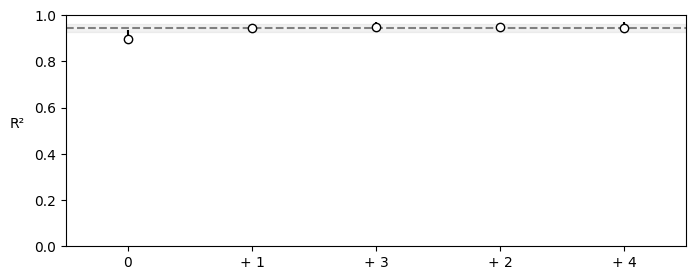

In [18]:
pmb.plot_variable_importance(vi_counties)

Total bedrooms alone is a strong predictor. Adding total rooms improves it a little but the rest of the variables don't do too much.

# Conclusion
In conclusion, bedrooms is likely the dominant predictor, total rooms following close behind. Population has some relationship, but I think the PDPs show that median house value and median income can be dropped as they don't substantially add anything. There is likley some interaction between bedrooms and total rooms.m